# Traffic Flow Prediction using LSTM & GRU

## Objective
Predict future traffic flow using historical traffic data and compare LSTM and GRU models.

---

### 1. Project Introduction

#### What problem are we solving?
We are predicting future traffic flow (e.g., the volume of vehicles on a road) based on historical traffic patterns.

#### Why is this a real-world problem?
Traffic congestion wastes time, fuel, and increases air pollution. Cities use traffic prediction to optimize traffic lights, schedule road maintenance, plan public transport routes, and help drivers bypass traffic jams.

#### What is time-series data?
Time-series data is a collection of observations recorded sequentially over regular intervals of time (e.g., hourly, daily). Unlike tabular data, the chronological order of the data points is critical; shuffling the data destroys the relationship we want to learn.

#### Why LSTM and GRU?
Standard artificial neural networks (ANNs) assume all inputs are independent of each other, which is not true for temporal data. Recurrent Neural Networks (RNNs) can process sequences, but struggle with long sequences. Long Short-Term Memory (LSTM) networks and Gated Recurrent Units (GRU) are specialized architectures designed to capture long-term temporal dependencies by utilizing "gates" to control the flow of information.

#### What we will build:
We will build a complete machine learning pipeline using TensorFlow/Keras to load, clean, scale, and transform traffic data into sequences. Then, we will train and compare both LSTM and GRU models under identical training conditions.

```
Historical Traffic Data
        ↓
Data Preprocessing
        ↓
Time-Series Sequences
        ↓
LSTM Model
        ↓
Traffic Prediction
```

```
Time-Series Sequences
        ↓
GRU Model
        ↓
Traffic Prediction
```

### 2. Import Required Libraries

First, we need to import our dependencies. We use `numpy` and `pandas` for handling data, `matplotlib` for creating clean plots, `sklearn` for metric calculation and scaling, and `tensorflow` for deep learning model creation.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries successfully imported!")

Libraries successfully imported!


### 3. Upload Dataset

Run the cell below to trigger the interactive file upload. Since the target file `Metro_Interstate_Traffic_Volume.csv.gz` (or its extracted CSV version) may already be present in `/content/`, the code will check for existing `.csv` or `.csv.gz` files first. If no files are detected, you will be prompted to manually upload your CSV file.

In [2]:
from google.colab import files

# Check if dataset is already in local directory
files_in_dir = os.listdir('/content')
csv_files = [f for f in files_in_dir if f.endswith('.csv') or f.endswith('.csv.gz')]

if len(csv_files) == 0:
    print("Please upload your traffic dataset manually (CSV or CSV.GZ format):")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
else:
    filename = os.path.join('/content', csv_files[0])
    print(f"Detected file in directory: {filename}")

# Load the dataset using pandas
df = pd.read_csv(filename)

# Display basic information
print(f"\nSuccessfully Loaded File: {filename}")
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Detected file in directory: /content/Metro_Interstate_Traffic_Volume.csv.gz

Successfully Loaded File: /content/Metro_Interstate_Traffic_Volume.csv.gz
Dataset Shape: (48204, 9)

First 5 rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918



Columns:
['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']


### 4. Dataset Understanding

We need to thoroughly inspect the structure, datatypes, missing entries, and overall summary statistics of our dataframe before making any architectural decisions.

In [3]:
print("--- DF Info ---")
df.info()

print("\n--- DF Describe ---")
display(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows count ---")
print(df.duplicated().sum())

--- DF Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB

--- DF Describe ---


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000



--- Missing Values ---
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

--- Duplicate Rows count ---
17


#### Define Your Target Columns

Based on your loaded dataset, map the time index column and the continuous traffic volume target column.

*If you uploaded a dataset with custom columns, modify the two variables below to match your dataset schema exactly.*

In [4]:
# Change these names if your uploaded dataset has different column names
TIME_COLUMN = 'date_time'
TARGET_COLUMN = 'traffic_volume'

print(f"Target column set to: {TARGET_COLUMN}")
print(f"Time column set to: {TIME_COLUMN}")

Target column set to: traffic_volume
Time column set to: date_time


### 5. Data Cleaning

In this step, we prepare our data chronologically. We ensure the time column is correctly converted to a `datetime` object, sort the observations chronologically, remove duplicates, and drop rows with empty targets.

In [5]:
# Convert to datetime format
df[TIME_COLUMN] = pd.to_datetime(df[TIME_COLUMN])

# Sort chronologically to preserve time dependency
df = df.sort_values(by=TIME_COLUMN).reset_index(drop=True)

# Drop rows where target variable might be missing or non-numeric
df = df.dropna(subset=[TARGET_COLUMN])

# Drop duplicates to prevent synthetic artificial patterns
df = df.drop_duplicates(subset=[TIME_COLUMN])

print(f"Cleaned dataset shape: {df.shape}")
display(df.head())

Cleaned dataset shape: (40575, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


### 6. Exploratory Data Analysis

Visualizing the distribution of traffic volume and temporal trends is critical for understanding seasonality and cycles.

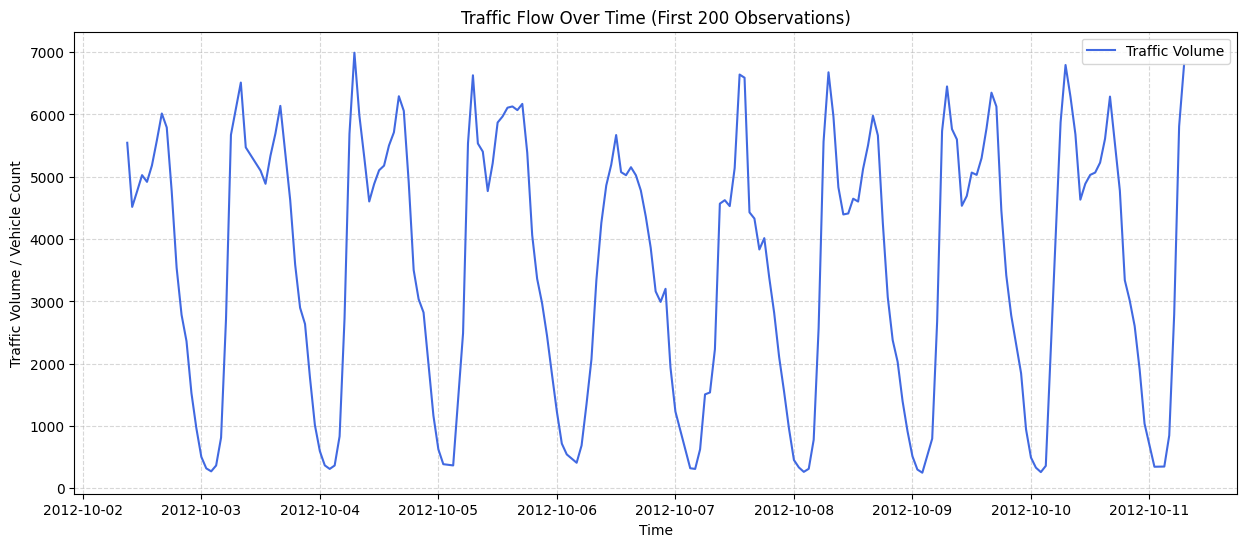

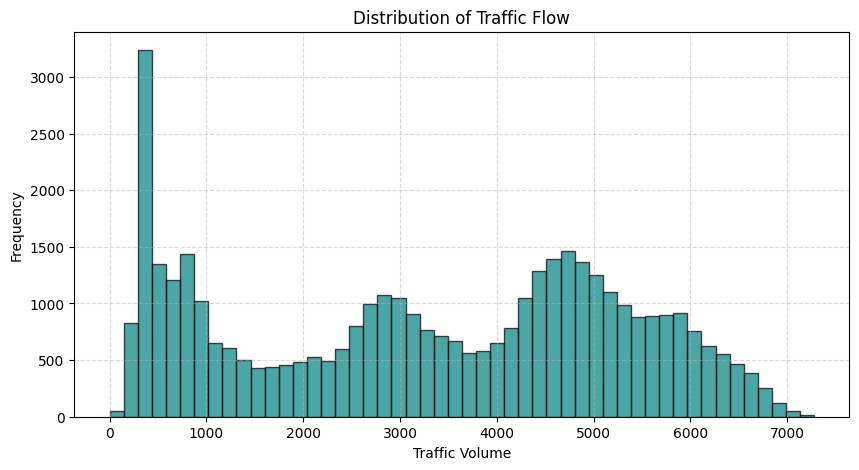

In [6]:
plt.figure(figsize=(15, 6))
plt.plot(df[TIME_COLUMN][:200], df[TARGET_COLUMN][:200], label='Traffic Volume', color='royalblue')
plt.title('Traffic Flow Over Time (First 200 Observations)')
plt.xlabel('Time')
plt.ylabel('Traffic Volume / Vehicle Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df[TARGET_COLUMN], bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribution of Traffic Flow')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 7. Explain Time-Series Sequences

Unlike traditional deep networks that accept tabular feature rows independently, recurrent networks require sliding sequence inputs.

If sequence length $N = 5$, and our series is:
`[100, 120, 150, 180, 200, 220]`

We slide a window to construct training pairs:
* **Input ($X$)**: `[100, 120, 150, 180, 200]` $\rightarrow$ **Output ($y$)**: `220`

### 8. Train-Test Split

For sequence problems, **never shuffle randomly**. Shuffling causes "data leakage", where the model cheats during training by observing information from the future. We must split our dataset chronologically, retaining the past for training and the future for validation.

In [7]:
# Extract target array as a 2D float array
data_raw = df[[TARGET_COLUMN]].values.astype('float32')

# Let's split 80% train, 20% test chronologically
split_idx = int(len(data_raw) * 0.80)
train_data = data_raw[:split_idx]
test_data = data_raw[split_idx:]

print(f"Training samples count: {len(train_data)}")
print(f"Testing samples count: {len(test_data)}")

Training samples count: 32460
Testing samples count: 8115


### 9. Feature Scaling

We utilize `MinMaxScaler` to scale values between $[0, 1]$. To prevent data leakage, we compute statistics (`fit`) exclusively on our training dataset, and subsequently transform both splits.

In [8]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print("Scaling finished.")

Scaling finished.


### 10. Create Time-Series Sequences

Let's define a function that slides our window of length `SEQUENCE_LENGTH` over the scaled sequential arrays and reshapes our array to `(samples, timesteps, features)` required by Keras recurrent layers.

In [9]:
SEQUENCE_LENGTH = 24  # Lookback window (e.g. 24 steps)

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQUENCE_LENGTH)

print(f"X_train shape: {X_train.shape} (Samples, Timesteps, Features)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (32436, 24, 1) (Samples, Timesteps, Features)
y_train shape: (32436, 1)
X_test shape: (8091, 24, 1)
y_test shape: (8091, 1)


### 11. Build LSTM Model

Let's construct a simple LSTM network with a dropout layer to prevent overfitting.

In [10]:
lstm_model = Sequential([
    LSTM(50, input_shape=(SEQUENCE_LENGTH, 1), return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
lstm_model.summary()

# Train for 1 epoch for classroom demonstration
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=1,
    batch_size=64
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

507/507 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0335 - mae: 0.1380 - val_loss: 0.0099 - val_mae: 0.0793


### 12. LSTM Training Visualization

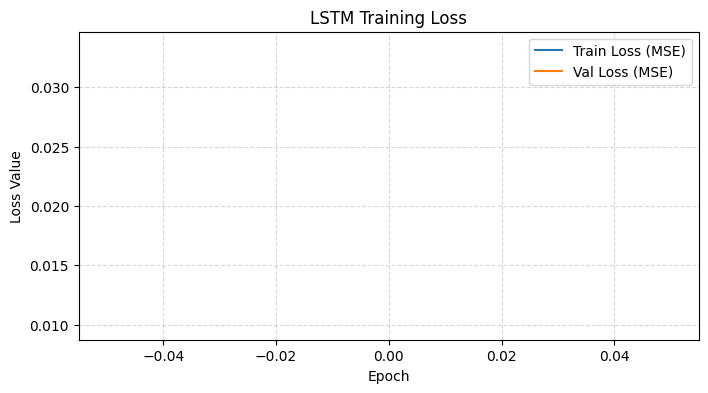

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(lstm_history.history['loss'], label='Train Loss (MSE)')
plt.plot(lstm_history.history['val_loss'], label='Val Loss (MSE)')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### 13. LSTM Predictions

We convert the predicted and actual sequence targets back to their original physical scale using our saved scaler.

In [12]:
lstm_preds_scaled = lstm_model.predict(X_test)

# Inverse scaling
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
y_test_actual = scaler.inverse_transform(y_test)

# Calculate metrics safely
lstm_mae = mean_absolute_error(y_test_actual, lstm_preds)
lstm_mse = mean_squared_error(y_test_actual, lstm_preds)
lstm_rmse = np.sqrt(lstm_mse)

# Handle zeros safely for MAPE
eps = 1.0
lstm_mape = np.mean(np.abs((y_test_actual - lstm_preds) / (y_test_actual + eps))) * 100

print("LSTM Metrics on Test Data:")
print(f"MAE: {lstm_mae:.2f}")
print(f"MSE: {lstm_mse:.2f}")
print(f"RMSE: {lstm_rmse:.2f}")
print(f"Safe MAPE: {lstm_mape:.2f}%")

253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM Metrics on Test Data:
MAE: 577.02
MSE: 525511.38
RMSE: 724.92
Safe MAPE: 39.87%


### 14. Actual vs Predicted Traffic — LSTM

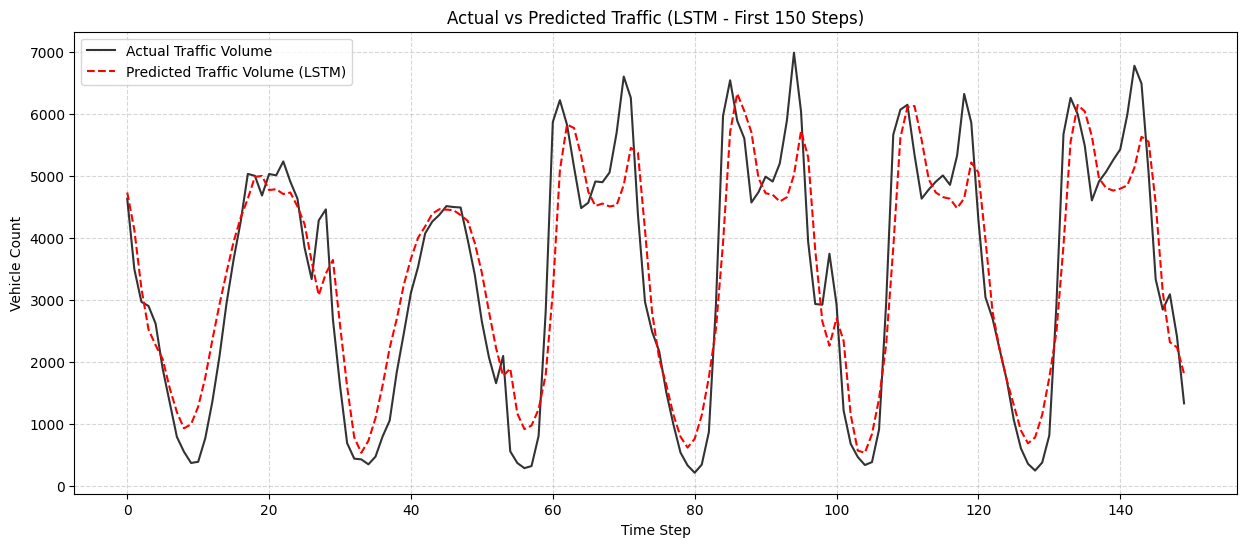

In [13]:
plt.figure(figsize=(15, 6))
plt.plot(y_test_actual[:150], label='Actual Traffic Volume', color='black', alpha=0.8)
plt.plot(lstm_preds[:150], label='Predicted Traffic Volume (LSTM)', color='red', linestyle='--')
plt.title('Actual vs Predicted Traffic (LSTM - First 150 Steps)')
plt.xlabel('Time Step')
plt.ylabel('Vehicle Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### 15. Build GRU Model

To make our architecture comparison fair, we train a GRU model with the identical dimension layout under the exact same parameters.

In [14]:
gru_model = Sequential([
    GRU(50, input_shape=(SEQUENCE_LENGTH, 1), return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
gru_model.summary()

# Train for 1 epoch
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=1,
    batch_size=64
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

507/507 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.0225 - mae: 0.1096 - val_loss: 0.0062 - val_mae: 0.0579


### 16. GRU Training Visualization

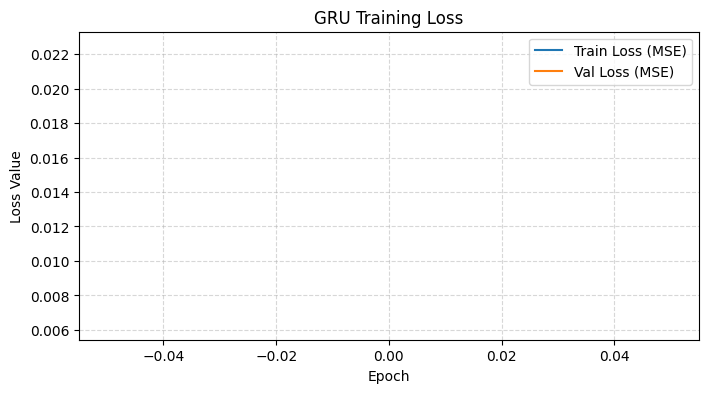

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(gru_history.history['loss'], label='Train Loss (MSE)')
plt.plot(gru_history.history['val_loss'], label='Val Loss (MSE)')
plt.title('GRU Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### 17. GRU Predictions

In [16]:
gru_preds_scaled = gru_model.predict(X_test)
gru_preds = scaler.inverse_transform(gru_preds_scaled)

gru_mae = mean_absolute_error(y_test_actual, gru_preds)
gru_mse = mean_squared_error(y_test_actual, gru_preds)
gru_rmse = np.sqrt(gru_mse)
gru_mape = np.mean(np.abs((y_test_actual - gru_preds) / (y_test_actual + eps))) * 100

print("GRU Metrics on Test Data:")
print(f"MAE: {gru_mae:.2f}")
print(f"MSE: {gru_mse:.2f}")
print(f"RMSE: {gru_rmse:.2f}")
print(f"Safe MAPE: {gru_mape:.2f}%")

253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
GRU Metrics on Test Data:
MAE: 421.77
MSE: 330785.16
RMSE: 575.14
Safe MAPE: 25.92%


### 18. Actual vs Predicted Traffic — GRU

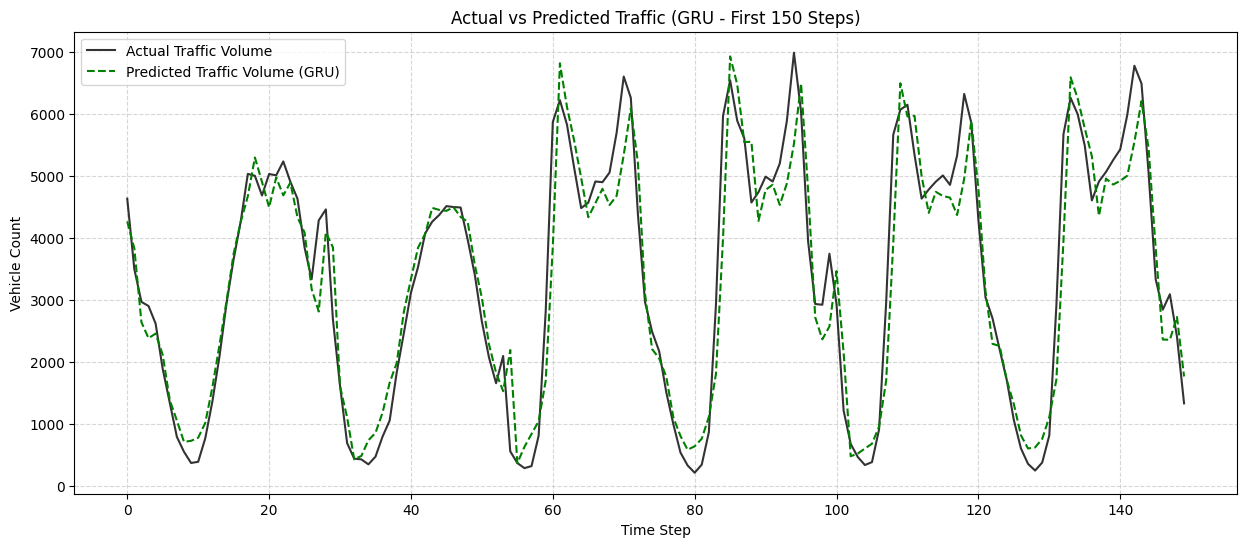

In [17]:
plt.figure(figsize=(15, 6))
plt.plot(y_test_actual[:150], label='Actual Traffic Volume', color='black', alpha=0.8)
plt.plot(gru_preds[:150], label='Predicted Traffic Volume (GRU)', color='green', linestyle='--')
plt.title('Actual vs Predicted Traffic (GRU - First 150 Steps)')
plt.xlabel('Time Step')
plt.ylabel('Vehicle Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### 19. LSTM vs GRU Comparison

Let's evaluate the summary performance of both sequential networks on the test dataset side-by-side.

,Metric,LSTM,GRU
0,MAE,577.016541,421.774445
1,MSE,525511.375000,330785.156250
2,RMSE,724.921634,575.139249
3,Safe MAPE (%),39.874165,25.918468


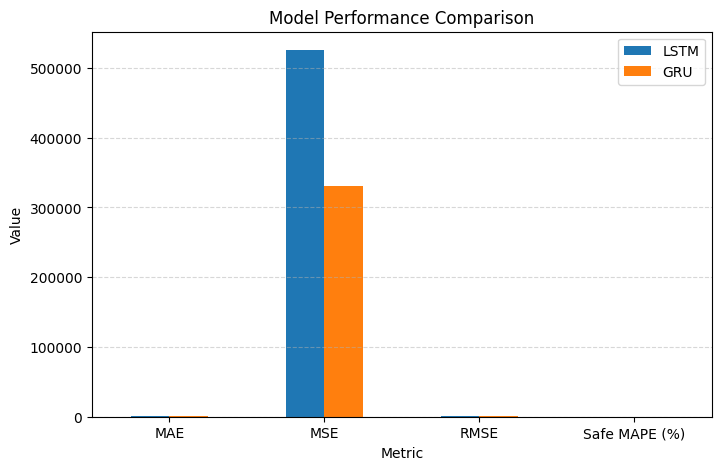

In [18]:
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'Safe MAPE (%)'],
    'LSTM': [lstm_mae, lstm_mse, lstm_rmse, lstm_mape],
    'GRU': [gru_mae, gru_mse, gru_rmse, gru_mape]
})

display(comparison_df)

# Plot simple bar chart
comparison_df.set_index('Metric')[['LSTM', 'GRU']].plot(kind='bar', figsize=(8, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 20. Single Future Prediction

Here, we take the most recent history block from our test set and predict the next time step.

In [19]:
latest_sequence = test_scaled[-SEQUENCE_LENGTH:] # Shape: (SEQUENCE_LENGTH, 1)
input_seq = np.expand_dims(latest_sequence, axis=0) # Shape: (1, SEQUENCE_LENGTH, 1)

# Predict using both models
lstm_single_scaled = lstm_model.predict(input_seq)
gru_single_scaled = gru_model.predict(input_seq)

# Inverse scale
lstm_single_pred = scaler.inverse_transform(lstm_single_scaled)[0][0]
gru_single_pred = scaler.inverse_transform(gru_single_scaled)[0][0]

print(f"Latest sequential input (original scale):\n {scaler.inverse_transform(latest_sequence).flatten()}\n")
print(f"Predicted next traffic using LSTM: {lstm_single_pred:.2f}")
print(f"Predicted next traffic using GRU: {gru_single_pred:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Latest sequential input (original scale):
 [1826.       920.       696.       364.       335.       444.
  802.      1175.      2002.      2882.      3701.0002  4049.0002
 4429.      4547.      4380.      4302.      4283.      4132.
 3947.      3543.      2781.      2159.      1450.       953.99994]

Predicted next traffic using LSTM: 1213.00
Predicted next traffic using GRU: 930.46


### 21. Explain the Complete Pipeline

```
Raw Traffic Data
       ↓ (Sort chronologically & clear missing entries)
Data Cleaning
       ↓ (Split chronologically to preserve future boundary)
Chronological Split
       ↓ (Normalize scale of training input strictly)
Feature Scaling
       ↓ (Create lookback window matrices)
Sequence Creation
       ↓ (Train sequences via temporal gates)
LSTM / GRU Models
       ↓ (Predict scaled outputs)
Model Inference
       ↓ (Invert scaler transformation)
Inverse Scaling
       ↓ (Evaluate absolute/squared difference metrics)
Evaluation Metrics
```

### 22. Concept Explanation

* **Sequential Data:** Data where index sequence matters (e.g. traffic volume over time). Shuffling data breaks dependencies.
* **Standard Neural Networks:** They contain no memory layer. Inputs are processed independently without contextual history.
* **RNN:** Recurrent Neural Networks introduce feedback loops to pass sequence values, but they suffer from vanishing gradients over long timesteps.
* **LSTM:** Outfitted with an internal Cell State and three gates (Forget, Input, Output) to protect and preserve long-term history.
* **GRU:** A streamlined variant of the LSTM. It replaces the separate cell state and hidden state with a single unified hidden state controlled by just two gates (Reset, Update), often resulting in faster execution speeds.

### 23. Viva / Interview Questions

1. **Why is traffic data considered time-series data?**
   * Answer: Because data is recorded chronologically over constant intervals, making adjacent values correlated.
2. **Why do we use LSTM?**
   * Answer: LSTMs can retain temporal trends over long ranges without running into vanishing gradients.
3. **What is the difference between RNN and LSTM?**
   * Answer: RNN contains basic feedback without gates, whereas LSTM controls memory updates using dedicated Forget, Input, and Output gates.
4. **What is the difference between LSTM and GRU?**
   * Answer: GRU is computationally simpler with 2 gates (Reset, Update) instead of 3, and lacks a separate cell state.
5. **What does sequence length mean?**
   * Answer: The historical context size or window count utilized to forecast the immediate future step.
6. **Why do we scale the data?**
   * Answer: Standardizes gradients during network propagation, preventing numerical instability.
7. **Why don't we randomly shuffle time-series data?**
   * Answer: Shuffling introduces future context to historical evaluation (data leakage), yielding artificial predictions.
8. **What is MAE?**
   * Answer: Mean Absolute Error - the average absolute deviation between predictions and actual targets.
9. **What is RMSE?**
   * Answer: Root Mean Squared Error - penalizes larger prediction errors heavily.
10. **What does the LSTM input shape mean?**
    * Answer: `(Samples, Timesteps, Features)`. This defines batch sample count, lookback sequences, and feature dimensions.

### 24. Practice Tasks

1. Modify `SEQUENCE_LENGTH = 12` and train both models again. Observe the changes in validation error.
2. Increase the amount of LSTM and GRU units from 50 to 100.
3. Change the train/test split index to `0.70` (70% training, 30% testing).
4. Try compiling using `'mean_absolute_error'` as the optimizer loss metric instead of `'mean_squared_error'`.
5. Increase model validation visual scope from `150` to the last `500` index steps.

## Conclusion

In this project, we successfully built and evaluated two recurrent deep learning architectures (LSTM and GRU) to model and predict complex traffic volume trends. We gained practical knowledge in formatting sequential windowed data structures, preventing temporal leakage during splitting, applying inverse scaler conversions, and comparing gating systems under equivalent environments. These patterns are directly applicable to other challenging real-world domains such as stock pricing, climate modeling, and demand forecasting.